# Can you see a street celebration from sensors? Rotterdam, 4 July 2026

On the night of **4 July 2026**, Morocco's World Cup win sent crowds and **fireworks** onto Rotterdam's
streets. This notebook asks a narrow, honest question: does a one-night mass celebration leave a
*measurable* trace in openly available remote / ground-sensing data, reachable through the
[`earthlens`](https://github.com/serapeum-org/earthlens) facade?

It is a companion to the June-2026 European heat-wave case study — same city, same `openaq` air-quality
backend — but a very different kind of signal: a brief, human, night-time event rather than a
continental weather pattern.

## Which signals could a celebration leave?

A street party means crowds, car processions, flares and fireworks. Each has a candidate sensor
signature — but only one is realistically detectable for a **single evening event in one city**, and
the fireworks-pollution literature (New Year's Eve, Diwali) tells us which:

| Candidate signal | Sensor / `earthlens` key | Detectable for one evening? |
|------------------|--------------------------|:---------------------------:|
| **Fireworks particulates** (PM2.5 / PM10) | ground stations — `openaq`, `sensor_community` | ✅ **the one that works** |
| Crowd / fireworks **seismic tremor** ("fan quake") | seismometers | ⚠️ needs raw *waveforms* — `fdsn` returns earthquake *catalogues*, not waveforms |
| Car-procession **NO₂** | Sentinel-5P TROPOMI (`gee`) | ❌ daytime-only ~13:30 overpass — never sees the evening |
| Fireworks **glow** | VIIRS night-lights (`gee`) | ❌ ~750 m pixels, one overpass — too coarse for one display |

Pyrotechnics reliably produce a **sharp evening/night PM spike** (2–16× baseline in the literature),
and — usefully — PM spikes while *gaseous* pollutants stay in range, so it is a clean, PM-specific
fingerprint. We test exactly that.

## Setup

Everything here is tabular air quality, so the toolkit is light: the `EarthLens` facade plus `pandas`
and `matplotlib`. OpenAQ needs a free API key, read from the `OPENAQ_API_KEY` environment variable
(set it before running).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from earthlens import EarthLens

OUT = Path("out") / "celebration"
OUT.mkdir(parents=True, exist_ok=True)

## Pull hourly particulates over Rotterdam

We fetch **hourly** PM10 and PM2.5 from the OpenAQ ground stations in a box over Rotterdam, spanning a
few days either side of the event so the celebration night can be compared to a normal one. Hourly (not
daily) resolution is essential — a fireworks spike lives in a two-to-three-hour window.

In [2]:
celeb = {}
for pollutant in ["pm10", "pm25"]:
    celeb[pollutant] = EarthLens(
        data_source="openaq",
        variables=[pollutant],
        temporal_resolution="hourly",
        start="2026-07-01", end="2026-07-06",
        lat_lim=[51.85, 52.0], lon_lim=[4.3, 4.6],
        path=str(OUT),
        max_locations=15,
    ).download(progress_bar=False)
{pollutant: df.station_id.nunique() for pollutant, df in celeb.items()}

2026-07-05 17:46:02.434 | INFO     | earthlens.openaq.backend:download:487 - OpenAQ download summary: 792 measurement(s) across 8 sensor(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\celebration\openaq_pm10_20260701_20260706.csv


2026-07-05 17:46:08.408 | INFO     | earthlens.openaq.backend:download:487 - OpenAQ download summary: 925 measurement(s) across 9 sensor(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\celebration\openaq_pm25_20260701_20260706.csv


{'pm10': 8, 'pm25': 9}

Collapse the stations to an hourly regional mean in local (Amsterdam) time, dropping the occasional negative / nodata sentinel, and peek at the celebration window itself.

In [3]:
def hourly_mean(df):
    valid = df[df["value"] > 0]  # drop negative / nodata sentinels
    local = pd.to_datetime(valid["datetime_utc"]).dt.tz_convert("Europe/Amsterdam").dt.tz_localize(None)
    return valid.assign(t=local).groupby("t")["value"].mean()

pm10_h, pm25_h = hourly_mean(celeb["pm10"]), hourly_mean(celeb["pm25"])
pm10_h.loc["2026-07-04 22:00":"2026-07-05 02:00"].round(1)

t
2026-07-04 22:00:00    12.6
2026-07-04 23:00:00    14.9
2026-07-05 00:00:00    21.8
2026-07-05 01:00:00    23.6
2026-07-05 02:00:00    17.2
Name: value, dtype: float64

## The celebration night vs the night before

We plot both particle sizes across 3–5 July and shade the celebration window (the evening of the 4th
into the small hours of the 5th). The test is simple: is there a night-time rise on the celebration
night that the *previous* night does not show?

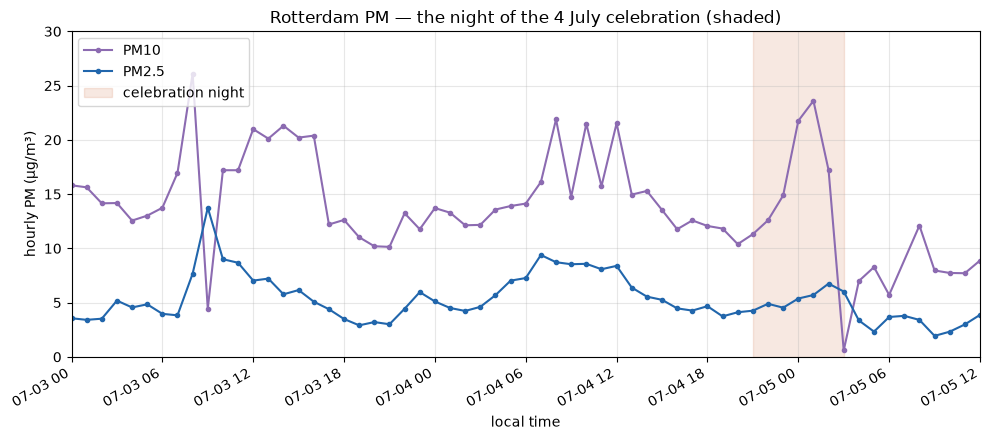

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(pm10_h.index, pm10_h.values, color="#8c6bb1", marker=".", label="PM10")
ax.plot(pm25_h.index, pm25_h.values, color="#2166ac", marker=".", label="PM2.5")
ax.axvspan(pd.Timestamp("2026-07-04 21:00"), pd.Timestamp("2026-07-05 03:00"),
           color="#c1440e", alpha=0.12, label="celebration night")
ax.set_xlim(pd.Timestamp("2026-07-03 00:00"), pd.Timestamp("2026-07-05 12:00"))
ax.set_ylim(0, 30)
ax.set_ylabel("hourly PM (µg/m³)"); ax.set_xlabel("local time")
ax.set_title("Rotterdam PM — the night of the 4 July celebration (shaded)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

There it is — faint, but real. **PM10 roughly doubles** on the celebration night, climbing from a flat
~13 µg/m³ the night before to **~24 µg/m³ around midnight–1 am** (PM2.5 nudges up in step), then falls
back by morning; the previous night shows no such bump. A late-night rise peaking in the small hours is
exactly the fireworks-and-crowds fingerprint the literature describes.

## Read it honestly

This is a **~2× bump of ~10 µg/m³**, not the 5–16× surge a New Year's Eve or Diwali produces. A
football celebration is smaller and more diffuse; European urban baselines are low; and a breezy coastal
night disperses the plume (stagnant air would amplify it). A single night-vs-night comparison is weak
statistics, and daytime PM on other days swings just as high. The clinching evidence — the pyrotechnic
metal tracers (potassium, strontium, barium) that let fireworks PM be source-apportioned — is not
something these regulatory monitors report.

And the signals that *don't* work are as instructive as the one that does:

- **Sentinel-5P NO₂** (car processions) — TROPOMI's single ~13:30 local overpass is daytime-only, so an
  evening event is never illuminated during its pass.
- **VIIRS night-lights** (fireworks glow) — one overpass a night at ~750 m: a brief display is far below
  the pixel and cadence needed.
- **Seismic "fan quakes"** — genuinely real (crowd jumping and fireworks register on urban seismometers,
  and KNMI runs stations right in the Rotterdam metro), but they live in the **continuous waveform**
  stream. `earthlens`' `fdsn` backend returns earthquake *event catalogues*, not waveforms, so capturing
  a tremor would need raw data pulled with `obspy` from ORFEUS/EIDA — outside this toolkit.

## Takeaway

A single street celebration sits **at the very edge of what open remote / ground sensing can reach**. Of
every candidate signal, only fireworks particulates on ground air-quality monitors leave a footprint you
can pull today — and even that is a faint, caveat-laden ~2× bump for an event this size, not a dramatic
spike. The honest ranking for a notebook like this:

1. **`openaq` / `sensor_community` particulates** — the one detectable signal; hourly PM10/PM2.5, night
   vs night. (Add `sensor_community`'s denser hyperlocal sensors to chase a sharper neighbourhood spike.)
2. **`fdsn` seismic** — promising in principle, but needs raw waveforms `earthlens` does not expose.
3. **Satellite (`gee`) NO₂ / night-lights** — not viable for a single evening event.

The larger lesson: remote sensing images the *environment* superbly, but a brief human event is mostly
below its threshold — worth knowing before you promise a picture of a party from space.